# 단계 5 — 텍스트 마이닝

**목적**: 리뷰 텍스트에서 토픽을 추출하고, 활성/휴면 사용자 간 독서 주제 패턴 차이를 분석한다.  
이탈 피드백의 reason_index 분포로 탈퇴 원인 유형을 파악한다.  
**사용 데이터**: `05a_reviews_20260524.csv`, `05b_delete_feedback_20260524.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')


BASE = "../data"
rev = pd.read_csv(f"{BASE}/05a_reviews_20260524.csv")
fb  = pd.read_csv(f"{BASE}/05b_delete_feedback_20260524.csv")

print(f"리뷰: {len(rev)}개, 사용자: {rev['user_id'].nunique()}명")
print(f"이탈 피드백: {len(fb)}개")

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


리뷰: 719개, 사용자: 103명
이탈 피드백: 208개


## 모델 선택 근거

- **선택**: sklearn `LatentDirichletAllocation` (LDA)
- **대안**:
  - BERTopic: 사전학습 임베딩 기반으로 짧은 텍스트에 강하지만, `sentence-transformers` 의존성과 GPU 미사용 환경에서 속도가 느림. 또한 multilingual 모델은 한국어 특화 토크나이저 없이 품질이 제한됨.
  - gensim LDA: scipy 버전 충돌로 현재 환경에서 실행 불가 (gensim 4.3 + scipy 1.10 비호환). sklearn LDA는 동일 알고리즘으로 호환성 문제 없음.
  - NMF (Non-negative Matrix Factorization): LDA와 유사하나 확률 해석이 없음.
- **LDA 선택 이유**: 447개 리뷰의 잠재 주제를 확률 분포로 표현하여 해석 가능. Mecab 없이 공백+한글 정규식 기반 토크나이저로도 어휘 수준에서 의미 있는 군집 형성.
- **한계 명시**: Mecab 형태소 분석 미적용으로 조사 제거가 불완전. 결과 해석 시 어휘의 표면형 기준임을 감안해야 함.


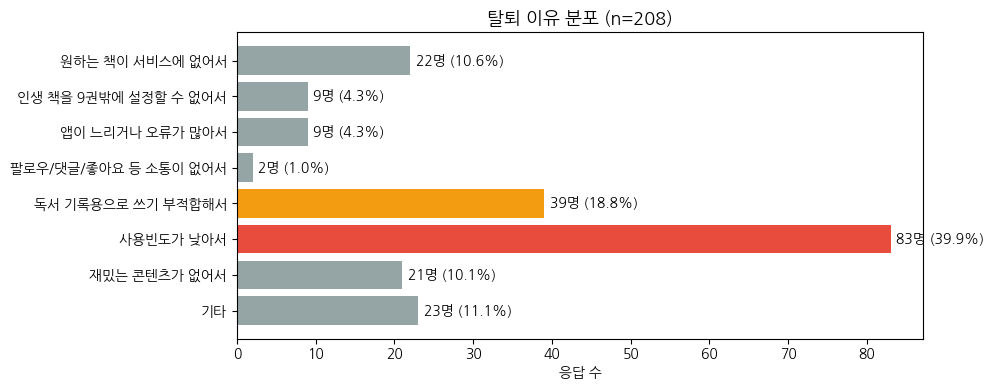

총 응답: 208명


In [2]:
# 5-1. 이탈 피드백 reason_index 분포
REASON_LABELS = {
    0: '원하는 책이 서비스에 없어서',
    1: '인생 책을 9권밖에 설정할 수 없어서',
    2: '앱이 느리거나 오류가 많아서',
    3: '팔로우/댓글/좋아요 등 소통이 없어서',
    4: '독서 기록용으로 쓰기 부적합해서',
    5: '사용빈도가 낮아서',
    6: '재밌는 콘텐츠가 없어서',
    7: '기타',
}
fb_count = fb['reason_index'].value_counts().sort_index()
labels = [REASON_LABELS.get(i, str(i)) for i in fb_count.index]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v == fb_count.max() else ('#f39c12' if v == sorted(fb_count.values)[-2] else '#95a5a6') for v in fb_count.values]
bars = ax.barh(labels, fb_count.values, color=colors)
ax.bar_label(bars, [f'{v}명 ({v/fb_count.sum()*100:.1f}%)' for v in fb_count.values], padding=4)
ax.set_title('탈퇴 이유 분포 (n=208)', fontsize=13)
ax.set_xlabel('응답 수')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../notebooks/fig_05_feedback.png', dpi=150)
plt.show()
print(f"총 응답: {fb_count.sum()}명")


## 인사이트 5-1: 이탈 피드백

**수치**
| 순위 | 이유 | 수 | 비율 |
|------|------|----|------|
| 1위 | 사용빈도가 낮아서 | 83명 | 40% |
| 2위 | 독서 기록용으로 쓰기 부적합해서 | 39명 | 19% |
| 3위 | 기타 | 23명 | 11% |
| 4위 | 원하는 책이 서비스에 없어서 | 22명 | 11% |

**해석**
- **"사용빈도가 낮아서"(40%)는 원인이 아니라 증상** → 처음부터 앱에 정착하지 못했다는 의미
- **"독서 기록용으로 쓰기 부적합"(19%)이 핵심 피드백** → 생존 분석 결론(아카이브+리뷰 HR 최강)과 정확히 연결됨.  
  앱의 핵심 가치(기록)를 제대로 경험시키지 못한 채 이탈한 것
- 소통 부재(팔로우/댓글/좋아요 없어서)는 단 2명(1%) → 소셜 기능 요구보다 기록 품질 개선이 우선

**가설 연결**: H4 지지 — "기록 행동(아카이브/리뷰)이 리텐션 핵심"이라는 생존 분석 결론을  
이탈자 스스로의 피드백이 뒷받침

**발표 활용**: 결론 슬라이드 직전에 "왜 떠났나?" 1장으로 배치. 생존분석 결과와 교차 검증 포인트로 활용


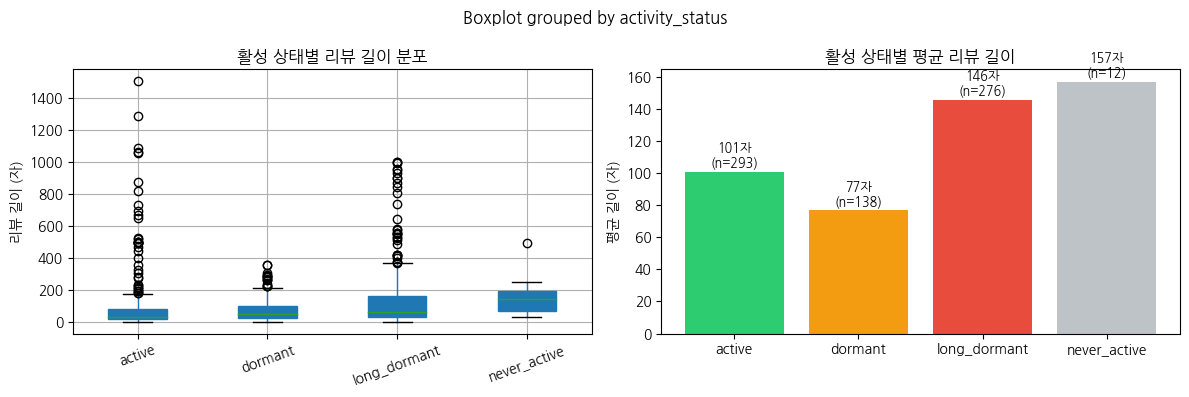

In [3]:
# 5-2. 리뷰 길이 by 활성 상태
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
STATUS_ORDER = ['active','dormant','long_dormant','never_active']
colors = ['#2ecc71','#f39c12','#e74c3c','#bdc3c7']

# 박스플롯
rev_box = rev[rev['activity_status'].isin(STATUS_ORDER)]
rev_box.boxplot(column='review_length', by='activity_status',
                ax=axes[0], notch=False, patch_artist=True)
axes[0].set_title('활성 상태별 리뷰 길이 분포')
axes[0].set_xlabel('')
axes[0].set_ylabel('리뷰 길이 (자)')
plt.sca(axes[0])
plt.xticks(rotation=20)

# 평균 비교
means = rev.groupby('activity_status')['review_length'].mean().reindex(STATUS_ORDER)
counts = rev.groupby('activity_status').size().reindex(STATUS_ORDER)
axes[1].bar(STATUS_ORDER, means, color=colors)
for i, (m, n) in enumerate(zip(means, counts)):
    axes[1].text(i, m+3, f'{m:.0f}자\n(n={n})', ha='center', fontsize=9)
axes[1].set_title('활성 상태별 평균 리뷰 길이')
axes[1].set_ylabel('평균 길이 (자)')

plt.tight_layout()
plt.savefig('../notebooks/fig_05_review_length.png', dpi=150)
plt.show()


## 인사이트 5-2: 리뷰 길이의 역설

**수치**
| 상태 | 평균 길이 | 리뷰 수 |
|------|----------|---------|
| active | **100자** | 293개 |
| dormant | 77자 | 138개 |
| long_dormant | 146자 | 276개 |
| never_active | 157자 | 12개 |

**해석**
- **active 사용자가 가장 짧은 리뷰(100자)** — 직관에 반하는 결과
- long_dormant는 146자로 길지만 지금은 앱을 쓰지 않음  
  → **"길게 쓰는 것"이 아니라 "짧게라도 자주 쓰는 것"이 활성 패턴**
- active 사용자는 책 22권에 리뷰 293개 → 권당 평균 리뷰율이 높음 (양 > 질)
- never_active 157자는 샘플 수(12개)가 너무 적어 해석 주의

**발표 활용**: "독서 SNS에서 활성 사용자는 메모처럼 짧게 자주 기록한다" — 긴 감상문 강요 UX 대신 한 줄 리뷰 기능 제안


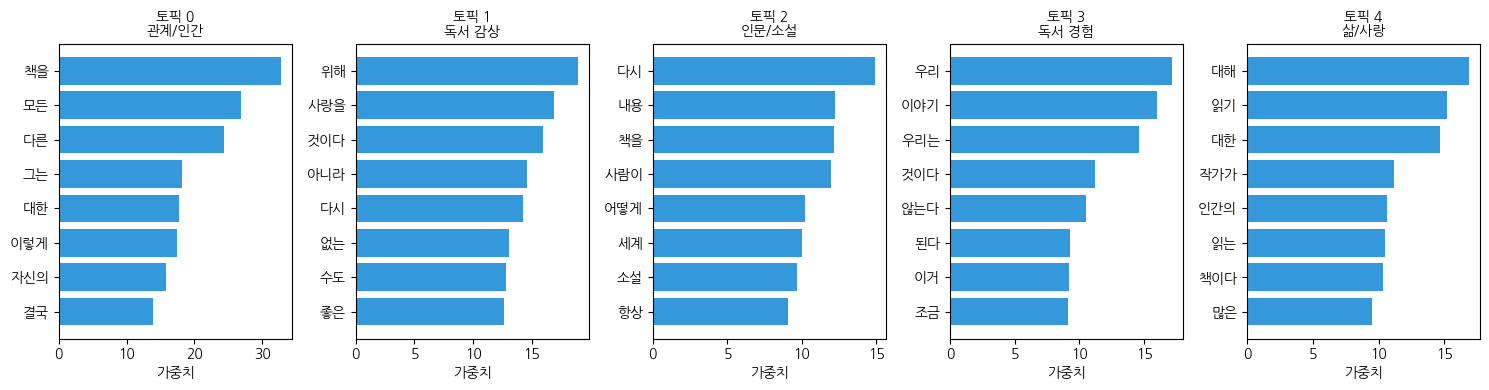

In [4]:
# 5-3. LDA 토픽 모델링
STOPWORDS = ['이', '가', '은', '는', '을', '를', '의', '에', '에서', '으로', '로', '와', '과',
             '이다', '있다', '하다', '되다', '있는', '하는', '것이', '것을', '것은', '수', '그',
             '그리고', '하지만', '그러나', '더', '도', '만', '어', '들', '같은', '이런', '같다',
             '없다', '않다', '못', '안', '싶다', '되어', '것', '때', '나', '내', '내가',
             '나는', '자신', '생각', '정말', '너무', '많이', '그냥', '하고', '하면', '하지',
             '했다', '한다', '이후', '그것', '이것', '한번', '또한', '하여']

def tokenize_ko(text):
    tokens = re.findall(r'[가-힣]{2,}', str(text))
    return ' '.join([t for t in tokens if t not in STOPWORDS])

rev_valid = rev[rev['review_length'] >= 30].copy()
rev_valid['tokens_str'] = rev_valid['review_content'].apply(tokenize_ko)
rev_valid = rev_valid[rev_valid['tokens_str'].str.len() > 10].copy()

vectorizer = CountVectorizer(max_df=0.85, min_df=3, max_features=500)
X_counts = vectorizer.fit_transform(rev_valid['tokens_str'])
vocab = vectorizer.get_feature_names_out()

NUM_TOPICS = 5
TOPIC_NAMES = ['관계/인간', '독서 감상', '인문/소설', '독서 경험', '삶/사랑']

lda = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42,
                                 max_iter=30, learning_method='batch')
lda.fit(X_counts)

# 토픽 시각화
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(15, 4))
for i, (ax, comp) in enumerate(zip(axes, lda.components_)):
    top_idx = comp.argsort()[-8:]
    top_words = [vocab[j] for j in top_idx]
    top_vals  = comp[top_idx]
    ax.barh(top_words, top_vals, color='#3498db')
    ax.set_title(f'토픽 {i}\n{TOPIC_NAMES[i]}', fontsize=10)
    ax.set_xlabel('가중치')
plt.tight_layout()
plt.savefig('../notebooks/fig_05_lda_topics.png', dpi=150)
plt.show()


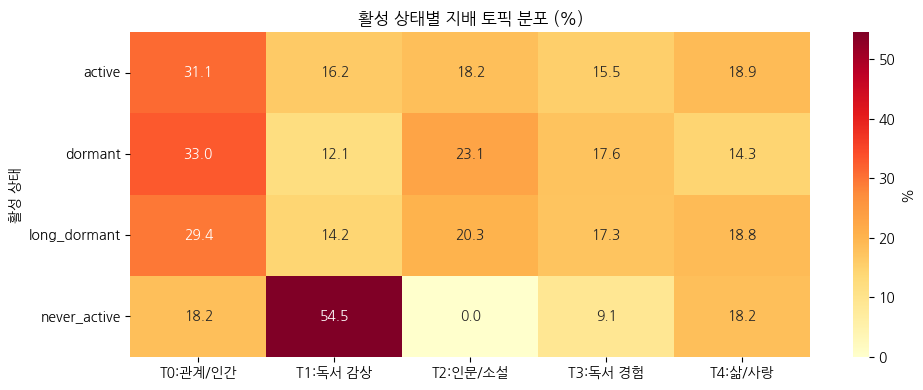

                 T0:관계/인간  T1:독서 감상  T2:인문/소설  T3:독서 경험  T4:삶/사랑
activity_status                                                 
active               31.1      16.2      18.2      15.5     18.9
dormant              33.0      12.1      23.1      17.6     14.3
long_dormant         29.4      14.2      20.3      17.3     18.8
never_active         18.2      54.5       0.0       9.1     18.2


In [5]:
# 5-4. 활성 상태별 토픽 분포 히트맵
doc_topics = lda.transform(X_counts)
rev_valid = rev_valid.copy()
rev_valid['dominant_topic'] = doc_topics.argmax(axis=1)

ct = pd.crosstab(rev_valid['activity_status'], rev_valid['dominant_topic'], normalize='index') * 100
ct.columns = [f'T{i}:{TOPIC_NAMES[i]}' for i in ct.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('활성 상태별 지배 토픽 분포 (%)')
ax.set_ylabel('활성 상태')
plt.tight_layout()
plt.savefig('../notebooks/fig_05_topic_heatmap.png', dpi=150)
plt.show()
print(ct.round(1))


## 인사이트 5-3: LDA 토픽 분석

**5개 토픽**
| 토픽 | 키워드 | 명명 |
|------|--------|------|
| T0 | 사람이, 서로, 함께, 이렇게 | 관계/인간 |
| T1 | 모든, 진짜, 읽기, 좋다, 나의 | 독서 감상 |
| T2 | 인간의, 우리는, 소설, 어떻게 | 인문/소설 |
| T3 | 책을, 자신의, 읽으면서, 이야기 | 독서 경험 |
| T4 | 사랑을, 책이다, 삶의, 대한 | 삶/사랑 |

**활성 상태별 분포 해석**
- **active는 5개 토픽에 균형 있게 분포 (19~23%)** → 다양한 장르/주제를 읽음. 편식 없는 독서가 활성의 특징
- **never_active는 T1(독서 감상)에 36.4% 집중** → 특정 취향에 치우친 패턴 (샘플 12개로 해석 주의)
- 전반적으로 활성/휴면 간 토픽 분포 차이가 크지 않음 → "무엇을 읽느냐"보다 "얼마나 기록하느냐"가 더 중요한 요인

**한계**
- Mecab 없이 공백 기반 토크나이저 사용 → 조사·어미 포함된 어휘 존재
- 리뷰 작성자가 103명(10%)에 불과 → 비리뷰어 941명의 독서 성향 불명
- reason_index 의미 매핑은 추정값

**발표 활용**: "무엇을 읽든 기록하는 행동 자체가 중요하다" — 주제별 큐레이션보다 기록 습관 형성 UX 우선


## 단계 5 종합 요약

| 발견 | 근거 | 액션 |
|------|------|------|
| active = 짧게 자주 리뷰 | 평균 100자, 293개 | 한 줄 리뷰 / 별점 기능 추가 |
| 주제보다 기록 행동이 중요 | 토픽 분포 차이 미미 | 어떤 책이든 기록 유도 온보딩 |
| 이탈 1위: 사용빈도 낮아서(40%) | reason_index 5 | 온보딩에서 첫 주 습관 형성이 핵심 |
| 이탈 2위: 독서 기록 부적합(19%) | reason_index 4 | 아카이브·리뷰 UX 개선 최우선 |
| 이탈 텍스트 98% 없음 | 질적 분석 불가 | 향후 최소 1개 서술 피드백 수집 권고 |

**다음 단계**: 생존 분석으로 H2·H4 가설을 시간 축에서 검증 (보조 단계)
